# EDA for
- https://www.kaggle.com/datasets/wardabilal/spotify-global-music-dataset-20092025/data?select=track_data_final.csv
- timeless hits from 2009-2023

In [290]:
from pathlib import Path
import pandas as pd

# Hämta datan från filen, vägen fungerar oberoende av vilken mapp projektet ligger i
file = Path.cwd().parent / 'data' / 'raw'

df = pd.read_csv(file/ 'track-data-final.csv')
df.head()

,track_id,track_name,track_number,track_popularity,track_duration_ms,explicit,artist_name,artist_popularity,artist_followers,artist_genres,album_id,album_name,album_release_date,album_total_tracks,album_type
0,6pymOcrCnMuCWdgGVTvUgP,3,57,61,213173,False,Britney Spears,80.0,17755451.0,['pop'],325wcm5wMnlfjmKZ8PXIIn,The Singles Collection,2009-11-09,58,compilation
1,2lWc1iJlz2NVcStV5fbtPG,Clouds,1,67,158760,False,BUNT.,69.0,293734.0,['stutter house'],2ArRQNLxf9t0O0gvmG5Vsj,Clouds,2023-01-13,1,single
2,1msEuwSBneBKpVCZQcFTsU,Forever & Always (Taylor’s Version),11,63,225328,False,Taylor Swift,100.0,145396321.0,[],4hDok0OAJd57SGIT8xuWJH,Fearless (Taylor's Version),2021-04-09,26,album
3,7bcy34fBT2ap1L4bfPsl9q,I Didn't Change My Number,2,72,158463,True,Billie Eilish,90.0,118692183.0,[],0JGOiO34nwfUdDrD612dOp,Happier Than Ever,2021-07-30,16,album
4,0GLfodYacy3BJE7AI3A8en,Man Down,7,57,267013,False,Rihanna,90.0,68997177.0,[],5QG3tjE5L9F6O2vCAPph38,Loud,2010-01-01,13,album


In [291]:
# se antalet rader och kolumner
rows, cols = df.shape
print(f"rows: {rows}, columns: {cols}")

rows: 8778, columns: 15


In [292]:
# Se de olika kolumnerna
df.columns

Index(['track_id', 'track_name', 'track_number', 'track_popularity',
       'track_duration_ms', 'explicit', 'artist_name', 'artist_popularity',
       'artist_followers', 'artist_genres', 'album_id', 'album_name',
       'album_release_date', 'album_total_tracks', 'album_type'],
      dtype='str')

In [293]:
# Se vilka kolumner som har Null-värde (kolla "entries" och "Non-Null", olika antal == Null-värde finns)
# Se datatyper
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8778 entries, 0 to 8777
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   track_id            8778 non-null   str    
 1   track_name          8776 non-null   str    
 2   track_number        8778 non-null   int64  
 3   track_popularity    8778 non-null   int64  
 4   track_duration_ms   8778 non-null   int64  
 5   explicit            8778 non-null   bool   
 6   artist_name         8774 non-null   str    
 7   artist_popularity   8774 non-null   float64
 8   artist_followers    8774 non-null   float64
 9   artist_genres       8774 non-null   str    
 10  album_id            8778 non-null   str    
 11  album_name          8776 non-null   str    
 12  album_release_date  8778 non-null   str    
 13  album_total_tracks  8778 non-null   int64  
 14  album_type          8778 non-null   str    
dtypes: bool(1), float64(2), int64(4), str(8)
memory usage: 2.0 MB


In [294]:
# Se olika uträkningar (medelvärde, max, min ...) på data med nummer(int, float)
df.describe()

,track_number,track_popularity,track_duration_ms,artist_popularity,artist_followers,album_total_tracks
count,8778.000000,8778.000000,8778.000000,8774.000000,8.774000e+03,8778.000000
mean,5.749487,52.232855,210157.791866,69.954981,2.435487e+07,13.779790
std,6.017938,24.075221,63326.841454,19.532783,3.813769e+07,11.797943
min,1.000000,0.000000,0.000000,0.000000,0.000000e+00,1.000000
25%,1.000000,39.000000,173921.250000,60.000000,5.152768e+05,6.000000
50%,4.000000,58.000000,207276.000000,74.000000,6.272266e+06,13.000000
75%,9.000000,71.000000,239693.250000,84.000000,3.055055e+07,17.000000
max,102.000000,100.000000,811077.000000,100.000000,1.455421e+08,181.000000


In [295]:
df["artist_name"].value_counts().head(3)

artist_name
Taylor Swift     330
The Weeknd       151
Ariana Grande    101
Name: count, dtype: int64

In [296]:
df["artist_followers"].value_counts().head(3)

artist_followers
145396321.0    140
145489371.0     91
145443567.0     87
Name: count, dtype: int64

In [297]:
df["artist_popularity"].value_counts().head(3)

artist_popularity
88.0    430
81.0    379
85.0    346
Name: count, dtype: int64

In [298]:
# Ca hälften av artister/raderna saknar genrer
df["artist_genres"].value_counts().head(3)

artist_genres
[]                4492
['soundtrack']     346
['pop']            303
Name: count, dtype: int64

In [299]:
df["track_popularity"].value_counts().head(3)

track_popularity
0     521
62    195
71    194
Name: count, dtype: int64

In [300]:
df["album_release_date"].value_counts()

album_release_date
2010-01-01    78
2013-01-01    76
1991-09-26    75
2012-01-01    69
2011-01-01    69
              ..
2025-05-06     1
2022-05-16     1
2018-11-08     1
2023-08-19     1
2001-03-21     1
Name: count, Length: 2390, dtype: int64

In [301]:
import duckdb

# Se antal artister med fler än tio miljoner följare
duckdb.sql("""--sql
SELECT
    artist_name,
    MAX(artist_followers) AS artist_followers
FROM df
WHERE artist_followers > 10000000
GROUP BY artist_name
ORDER BY MAX(artist_followers) DESC;
""").df().value_counts().head(3)


artist_name    artist_followers
Taylor Swift   145542136.0         1
Ed Sheeran     122802777.0         1
Billie Eilish  118797451.0         1
Name: count, dtype: int64

In [302]:
# Ser att samma artist har olika många följare på olika rader
duckdb.sql("""--sql
SELECT
    artist_name,
    artist_followers
FROM df
WHERE artist_followers > 10000000
ORDER BY artist_name;
""").df().head(3)

,artist_name,artist_followers
0,21 Savage,23806936.0
1,21 Savage,23806936.0
2,21 Savage,23822155.0


In [303]:
# Se spannet på år för låtar i filen
duckdb.sql("""--sql
SELECT
    album_release_date
FROM df
ORDER BY album_release_date;
""").df().head(4)

,album_release_date
0,0000
1,0000
2,1952-09-12
3,1958-01-01


In [304]:
# Se hur många olika release datum som finns samt antal releaser
duckdb.sql("""--sql
SELECT
    album_release_date,
    COUNT(*) AS amount
FROM df
GROUP BY album_release_date
""").df().head(3)

,album_release_date,amount
0,2013-02-17,1
1,2002-05-14,1
2,2015-12-01,1


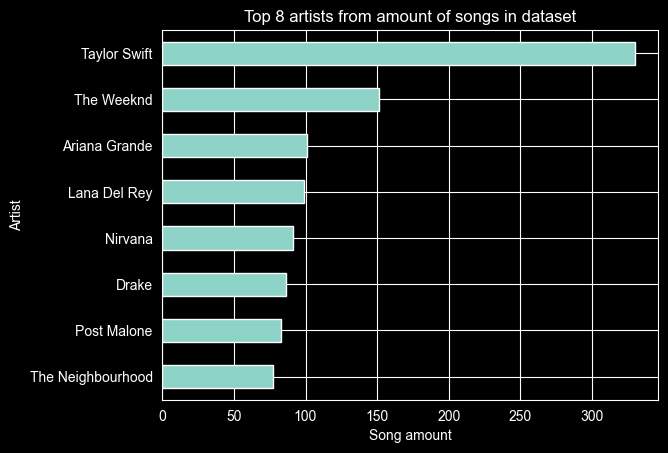

In [305]:
ax = df["artist_name"].value_counts().head(8).plot(
    kind= "barh",
    title= "Top 8 artists from amount of songs in dataset",
    xlabel= "Song amount",
    ylabel= "Artist"
)

ax.invert_yaxis()

In [306]:
clean_album_release = df
clean_album_release["album_release_date"] = pd.to_datetime(clean_album_release["album_release_date"], format="%Y-%m-%d", errors="coerce")

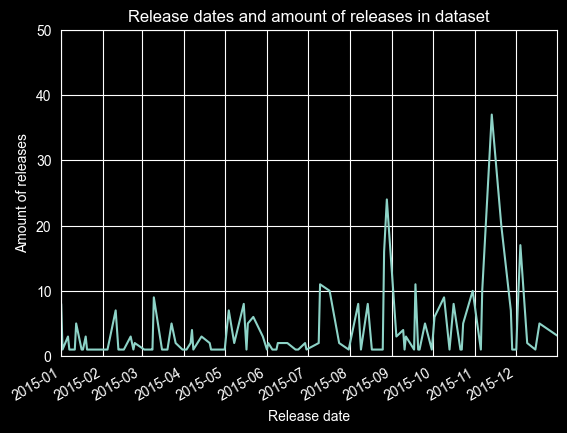

In [317]:
# Se utvecklingen av album släpp över en period

ax = clean_album_release["album_release_date"].value_counts().sort_index().plot(
    kind="line",
    title= "Release dates and amount of releases in dataset",
    xlabel= "Release date",
    ylabel= "Amount of releases",
)
ax.set_ylim(0, 50)
ax.set_xlim(pd.Timestamp('2015-01-01'), pd.Timestamp('2015-12-31'))
